- https://www.nature.com/articles/s41597-025-04845-9.epdf?sharing_token=ed56EmuGRjyoUz3B10hde9RgN0jAjWel9jnR3ZoTv0NvUXFVzZzxtTv9vc3PSprm92XcexrPldKNGGo7rKJsoQx6wbM2NvcsIWcV3oO8GUJzrxg1y_tuacYW4EckGMEbc4SlbjDd23PXde-F-d_Nz9-HFfUwS_vHg5pePs3EOZ0%3D
- 기본 제공 EDA: `Wearable_Dataset_0518`

# Wearable Device Dataset from Induced Stress and Structured Exercise Sessions

- 급성 스트레스 유도 상황 & 유산소, 무산소 운동 세션동안 기록된 생리신호
- Empatica E4로…
    - 피부전도도(EDA)
    - 피부온도
    - 3축 가속도
    - 혈액량 맥파(PPG)
    
    → 심박수(HR), 심박변이도(HRV) 도출 가능
    
- 스트레스 유도 방법: 수학 과제, 감정 과제
- 유산소, 무산소 방법: 고정식 자전거 루틴 사용
- 피험자 정보: 19~30세 남녀
    - 스트레스: 36명(남18, 여18)
    - 유산소: 30명
    - 무산소 31명
- 데이터셋 만든 이유: 인공췌장 연구를 위해서. (스트레스/유산소/무산소 자동인지기술)
    
    → 운동 & 스트레스 둘 다 HR증가, HRV 변화, EDA 변화함. 그걸 구분하는게 중요.

#### Stress Protocol

→ v2는 v1 경험 바탕으로 프로토콜 개선

(1) Baseline 3분: **안정** 상태

(2) Stroop test: 색깔-단어 충돌 과제로 **스트레스 유발**

(3) 5분 **휴식**

(4) Trier Mental Challenge Test(TMCT): 5초 제한 수학문제를 시끄러운 소리와 풀고 큰소리로 대답해하게해서 **스트레스 유발**

(5) 5분 **휴식**

(6) Real opinion: 30초간 어떤 주게 자기 의견 말하게함.

(7) Opposite opinion: 30초간 의견 반박 과제로 **감정적 스트레스 유발**

(8) Substract test: 30초간 역산 과제로 **정신적 스트레스 유발**

+ 각 단계 전후마다 현재 스트레스 정도를 1~10으로 조사. self-report가 있음.

- v2에서 개선된 점
    - Stroop 제거
    - 휴식 시간 증가
    - relaxing video 추가
    - 원격 진행
    
    → 휴식 상태를 더 안정적으로 만들기 위해서.
    
- Stress label
    - TMCT
    - opinion task
    - subtraction task
    - (v1에선 Stroop 포함)
- Rest label
    - baseline
    - rest period

#### Data Records

STRESS/subject별 폴더(S01, S02,…)/BVP.csv, EDA.csv, tags.csv,…

시작 시간(UTC) | sampling rate(HZ) | 실제 데이터

→ 연구진은 IBI.csv를 안씀. exercise 데이터에서 missing이 많았음.

  BVP → 직접 peak detection 해서 HRV 계산함.

- tags.csv에 각 구간별 timestamp가 있음 → segmentation하면 됨.
    
    ```python
    | V1 구간           | tag |
    | ---------------- | ------ |
    | Baseline         | 1~2    |
    | Stroop           | 3~4    |
    | First Rest       | 4~5    |
    | TMCT             | 5~6    |
    | Second Rest      | 6~7    |
    | Real Opinion     | 7~8    |
    | Opposite Opinion | 9~10   |
    | Subtract Test    | 11~12  |
    
    ```
    
    ```python
    | V2 구간           | tag |
    | ---------------- | --- |
    | Baseline         | 1~2 |
    | TMCT             | 2~3 |
    | First Rest       | 3~4 |
    | Real Opinion     | 4~5 |
    | Opposite Opinion | 5~6 |
    | Second Rest      | 6~7 |
    | Subtract         | 7~8 |
    
    ```
    
- stress_level_v1/v2.csv는 self-report
- 특이사항: recording 도중 연결 끊김 / Empatica 세션 분리 저장
    - S11 aerobic → split into two parts
    - S16 anaerobic → split into two parts
    - f14 stress → split into two parts


```python
C:.
└─Wearable_Dataset
    ├─AEROBIC
    │  ├─f01
    │  ├─f02
    │  ├─f03
    │  ├─f04
    │  ├─f05
    │  ├─f06
    │  ├─f07
    │  ├─f08
    │  ├─f09
    │  ├─f10
    │  ├─f11
    │  ├─f12
    │  ├─f13
    │  ├─S01
    │  ├─S02
    │  ├─S03
    │  ├─S04
    │  ├─S05
    │  ├─S06
    │  ├─S07
    │  ├─S08
    │  ├─S09
    │  ├─S10
    │  ├─S11_a
    │  ├─S11_b
    │  ├─S13
    │  ├─S14
    │  ├─S15
    │  ├─S16
    │  ├─S17
    │  └─S18
    ├─ANAEROBIC
    │  ├─f01
    │  ├─f02
    │  ├─f03
    │  ├─f04
    │  ├─f05
    │  ├─f06
    │  ├─f07
    │  ├─f08
    │  ├─f09
    │  ├─f10
    │  ├─f11
    │  ├─f12
    │  ├─f13
    │  ├─S01
    │  ├─S02
    │  ├─S03
    │  ├─S04
    │  ├─S05
    │  ├─S06
    │  ├─S07
    │  ├─S08
    │  ├─S09
    │  ├─S10
    │  ├─S11
    │  ├─S12
    │  ├─S13
    │  ├─S14
    │  ├─S15
    │  ├─S16_a
    │  ├─S16_b
    │  ├─S17
    │  └─S18
    └─STRESS
        ├─f01
        ├─f02
        ├─f03
        ├─f04
        ├─f05
        ├─f06
        ├─f07
        ├─f08
        ├─f09
        ├─f10
        ├─f11
        ├─f12
        ├─f13
        ├─f14_a
        ├─f14_b
        ├─f15
        ├─f16
        ├─f17
        ├─f18
        ├─S01
        ├─S02
        ├─S03
        ├─S04
        ├─S05
        ├─S06
        ├─S07
        ├─S08
        ├─S09
        ├─S10
        ├─S11
        ├─S12
        ├─S13
        ├─S14
        ├─S15
        ├─S16
        ├─S17
        └─S18
```

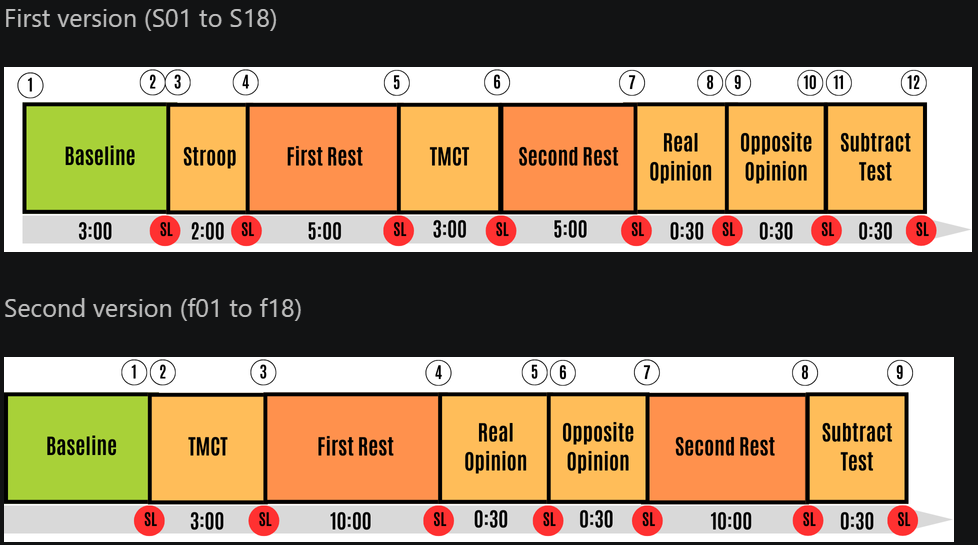

#### Load Data

In [2]:
import os
import re
import numpy as np
import pandas as pd
from pandas.errors import EmptyDataError

DATA_ROOT = r"/content/drive/MyDrive/Colab Notebooks/datasets/Wearable-device-dataset/Wearable_Dataset"
STRESS_ROOT = os.path.join(DATA_ROOT, "STRESS")

def read_bvp_meta(path):
    with open(path, "r", encoding="utf-8") as f:
        lines = [line.strip() for line in f.readlines() if line.strip()]

    start_time = pd.to_datetime(lines[0])
    fs = float(lines[1])
    n_samples = len(lines) - 2
    duration_sec = n_samples / fs
    end_time = start_time + pd.to_timedelta(duration_sec, unit="s")

    return start_time, end_time, fs, n_samples, duration_sec


def read_tags(path):
    if os.path.getsize(path) == 0:
        return []

    try:
        tags = pd.read_csv(path, header=None)
    except EmptyDataError:
        return []

    if tags.empty:
        return []

    tags[0] = pd.to_datetime(tags[0])
    return tags[0].tolist()


def sec_to_minsec(sec):
    m = int(sec // 60)
    s = int(round(sec % 60))
    return f"{m}:{s:02d}"


V2_SEGMENTS = [
    ("Baseline",         "bvp_start", 0, "Rest"),
    ("TMCT",             1, 2, "Stress"),
    ("First Rest",       2, 3, "Rest"),
    ("Real Opinion",     3, 4, "Stress"),
    ("Opposite Opinion", 5, 6, "Stress"),
    ("Second Rest",      6, 7, "Rest"),
    ("Subtract Test",    7, 8, "Stress"),
]

rows = []
segment_rows = []
skipped = []

# f01~f18 중 split 폴더(f14_a, f14_b)는 일단 제외
subjects = sorted([
    d for d in os.listdir(STRESS_ROOT)
    if re.fullmatch(r"f\d{2}", d) and os.path.isdir(os.path.join(STRESS_ROOT, d))
])

print("v2 subjects:", subjects)
print("number of v2 subjects:", len(subjects))

for subject in subjects:
    subj_dir = os.path.join(STRESS_ROOT, subject)
    bvp_path = os.path.join(subj_dir, "BVP.csv")
    tags_path = os.path.join(subj_dir, "tags.csv")

    if not os.path.exists(bvp_path) or not os.path.exists(tags_path):
        skipped.append((subject, "missing BVP.csv or tags.csv"))
        continue

    try:
        bvp_start, bvp_end, fs, n_samples, bvp_duration = read_bvp_meta(bvp_path)
        tags = read_tags(tags_path)
    except Exception as e:
        skipped.append((subject, str(e)))
        continue

    if len(tags) < 9:
        skipped.append((subject, f"tags count < 9 ({len(tags)})"))
        continue

    rows.append({
        "subject": subject,
        "bvp_start": bvp_start,
        "bvp_end": bvp_end,
        "fs": fs,
        "n_samples": n_samples,
        "bvp_duration_sec": bvp_duration,
        "bvp_duration_min": bvp_duration / 60,
        "num_tags": len(tags),
        "first_tag_offset_sec": (tags[0] - bvp_start).total_seconds(),
        "last_tag_offset_sec": (tags[-1] - bvp_start).total_seconds(),
    })

    print("\n" + "=" * 80)
    print(f"[{subject}]")
    print(f"BVP duration : {bvp_duration/60:.2f} min ({sec_to_minsec(bvp_duration)})")
    print(f"BVP fs       : {fs} Hz")
    print(f"tags count   : {len(tags)}")

    print("\nMapped v2 segments:")
    for seg_name, start_ref, end_ref, label in V2_SEGMENTS:
        if start_ref == "bvp_start":
            start_t = bvp_start
        else:
            start_t = tags[start_ref]

        end_t = tags[end_ref]
        dur = (end_t - start_t).total_seconds()

        segment_rows.append({
            "subject": subject,
            "segment": seg_name,
            "label": label,
            "start": start_t,
            "end": end_t,
            "duration_sec": dur,
            "duration_min": dur / 60,
        })

        print(f"  {seg_name:16s} | {label:6s} | {dur:7.2f}s | {sec_to_minsec(dur)}")

summary_df = pd.DataFrame(rows)
segment_df = pd.DataFrame(segment_rows)

print("\n\nSUMMARY BY SUBJECT")
print(summary_df[[
    "subject", "fs", "n_samples", "bvp_duration_min",
    "num_tags", "first_tag_offset_sec", "last_tag_offset_sec"
]].to_string(index=False))

print("\n\nSEGMENT DURATION SUMMARY")
print(segment_df.groupby(["segment", "label"])["duration_sec"].describe())

print("\n\nSKIPPED")
for s, reason in skipped:
    print(f"{s}: {reason}")

summary_df.to_csv("v2_bvp_tags_load_check_summary.csv", index=False, encoding="utf-8-sig")
segment_df.to_csv("v2_bvp_tags_segment_check.csv", index=False, encoding="utf-8-sig")

v2 subjects: ['f01', 'f02', 'f03', 'f04', 'f05', 'f06', 'f07', 'f08', 'f09', 'f10', 'f11', 'f12', 'f13', 'f15', 'f16', 'f17', 'f18']
number of v2 subjects: 17

[f01]
BVP duration : 54.21 min (54:12)
BVP fs       : 64.0 Hz
tags count   : 9

Mapped v2 segments:
  Baseline         | Rest   |  287.00s | 4:47
  TMCT             | Stress |  452.00s | 7:32
  First Rest       | Rest   |  854.00s | 14:14
  Real Opinion     | Stress |   37.00s | 0:37
  Opposite Opinion | Stress |   32.00s | 0:32
  Second Rest      | Rest   | 1169.00s | 19:29
  Subtract Test    | Stress |   26.00s | 0:26

[f02]
BVP duration : 49.61 min (49:37)
BVP fs       : 64.0 Hz
tags count   : 9

Mapped v2 segments:
  Baseline         | Rest   |  851.00s | 14:11
  TMCT             | Stress |  379.00s | 6:19
  First Rest       | Rest   |  792.00s | 13:12
  Real Opinion     | Stress |   42.00s | 0:42
  Opposite Opinion | Stress |   35.00s | 0:35
  Second Rest      | Rest   |  439.00s | 7:19
  Subtract Test    | Stress |   31.00

#### without baseline

In [4]:
import os
import re
import numpy as np
import pandas as pd
from pandas.errors import EmptyDataError

DATA_ROOT = r"/content/drive/MyDrive/Colab Notebooks/datasets/Wearable-device-dataset/Wearable_Dataset"
STRESS_ROOT = os.path.join(DATA_ROOT, "STRESS")

def read_bvp_meta(path):
    with open(path, "r", encoding="utf-8") as f:
        lines = [line.strip() for line in f.readlines() if line.strip()]

    start_time = pd.to_datetime(lines[0])
    fs = float(lines[1])
    n_samples = len(lines) - 2
    duration_sec = n_samples / fs
    end_time = start_time + pd.to_timedelta(duration_sec, unit="s")

    return start_time, end_time, fs, n_samples, duration_sec


def read_tags(path):
    if os.path.getsize(path) == 0:
        return []

    try:
        tags = pd.read_csv(path, header=None)
    except EmptyDataError:
        return []

    if tags.empty:
        return []

    tags[0] = pd.to_datetime(tags[0])
    return tags[0].tolist()


def sec_to_minsec(sec):
    m = int(sec // 60)
    s = int(round(sec % 60))
    return f"{m}:{s:02d}"


V2_SEGMENTS = [
    # Baseline 제외

    ("TMCT",             1, 2, "Stress"),
    ("First Rest",       2, 3, "Rest"),
    ("Real Opinion",     3, 4, "Stress"),
    ("Opposite Opinion", 5, 6, "Stress"),
    ("Second Rest",      6, 7, "Rest"),
    ("Subtract Test",    7, 8, "Stress"),
]

rows = []
segment_rows = []
skipped = []

# f01~f18 중 split 폴더(f14_a, f14_b)는 일단 제외
subjects = sorted([
    d for d in os.listdir(STRESS_ROOT)
    if re.fullmatch(r"f\d{2}", d) and os.path.isdir(os.path.join(STRESS_ROOT, d))
])

print("v2 subjects:", subjects)
print("number of v2 subjects:", len(subjects))

for subject in subjects:
    subj_dir = os.path.join(STRESS_ROOT, subject)
    bvp_path = os.path.join(subj_dir, "BVP.csv")
    tags_path = os.path.join(subj_dir, "tags.csv")

    if not os.path.exists(bvp_path) or not os.path.exists(tags_path):
        skipped.append((subject, "missing BVP.csv or tags.csv"))
        continue

    try:
        bvp_start, bvp_end, fs, n_samples, bvp_duration = read_bvp_meta(bvp_path)
        tags = read_tags(tags_path)
    except Exception as e:
        skipped.append((subject, str(e)))
        continue

    if len(tags) < 9:
        skipped.append((subject, f"tags count < 9 ({len(tags)})"))
        continue

    rows.append({
        "subject": subject,
        "bvp_start": bvp_start,
        "bvp_end": bvp_end,
        "fs": fs,
        "n_samples": n_samples,
        "bvp_duration_sec": bvp_duration,
        "bvp_duration_min": bvp_duration / 60,
        "num_tags": len(tags),
        "first_tag_offset_sec": (tags[0] - bvp_start).total_seconds(),
        "last_tag_offset_sec": (tags[-1] - bvp_start).total_seconds(),
    })

    print("\n" + "=" * 80)
    print(f"[{subject}]")
    print(f"BVP duration : {bvp_duration/60:.2f} min ({sec_to_minsec(bvp_duration)})")
    print(f"BVP fs       : {fs} Hz")
    print(f"tags count   : {len(tags)}")

    print("\nMapped v2 segments:")
    for seg_name, start_ref, end_ref, label in V2_SEGMENTS:
        if start_ref == "bvp_start":
            start_t = bvp_start
        else:
            start_t = tags[start_ref]

        end_t = tags[end_ref]
        dur = (end_t - start_t).total_seconds()

        segment_rows.append({
            "subject": subject,
            "segment": seg_name,
            "label": label,
            "start": start_t,
            "end": end_t,
            "duration_sec": dur,
            "duration_min": dur / 60,
        })

        print(f"  {seg_name:16s} | {label:6s} | {dur:7.2f}s | {sec_to_minsec(dur)}")

summary_df = pd.DataFrame(rows)
segment_df = pd.DataFrame(segment_rows)

print("\n\nSUMMARY BY SUBJECT")
print(summary_df[[
    "subject", "fs", "n_samples", "bvp_duration_min",
    "num_tags", "first_tag_offset_sec", "last_tag_offset_sec"
]].to_string(index=False))

print("\n\nSEGMENT DURATION SUMMARY")
print(segment_df.groupby(["segment", "label"])["duration_sec"].describe())

print("\n\nSKIPPED")
for s, reason in skipped:
    print(f"{s}: {reason}")

summary_df.to_csv("v2_bvp_tags_load_check_summary_no_baseline.csv", index=False, encoding="utf-8-sig")
segment_df.to_csv("v2_bvp_tags_segment_check_no_baseline.csv", index=False, encoding="utf-8-sig")

v2 subjects: ['f01', 'f02', 'f03', 'f04', 'f05', 'f06', 'f07', 'f08', 'f09', 'f10', 'f11', 'f12', 'f13', 'f15', 'f16', 'f17', 'f18']
number of v2 subjects: 17

[f01]
BVP duration : 54.21 min (54:12)
BVP fs       : 64.0 Hz
tags count   : 9

Mapped v2 segments:
  TMCT             | Stress |  452.00s | 7:32
  First Rest       | Rest   |  854.00s | 14:14
  Real Opinion     | Stress |   37.00s | 0:37
  Opposite Opinion | Stress |   32.00s | 0:32
  Second Rest      | Rest   | 1169.00s | 19:29
  Subtract Test    | Stress |   26.00s | 0:26

[f02]
BVP duration : 49.61 min (49:37)
BVP fs       : 64.0 Hz
tags count   : 9

Mapped v2 segments:
  TMCT             | Stress |  379.00s | 6:19
  First Rest       | Rest   |  792.00s | 13:12
  Real Opinion     | Stress |   42.00s | 0:42
  Opposite Opinion | Stress |   35.00s | 0:35
  Second Rest      | Rest   |  439.00s | 7:19
  Subtract Test    | Stress |   31.00s | 0:31

[f03]
BVP duration : 59.93 min (59:56)
BVP fs       : 64.0 Hz
tags count   : 9

Map